In [172]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from netCDF4 import Dataset

In [198]:
id = 0

In [211]:
path = "/Users/pp/data/Simulations/A08_Hydraulics_standalone/2024/swiss/LHS/k_lower_layer_reduced"
path = "/Users/pp/data/Simulations/A08_Hydraulics_standalone/2024/swiss/LHS/constraind_kylem"
path = "/Users/pp/data/Simulations/A08_Hydraulics_standalone/2024/swiss/LHS/constraind_more_kylem"
path = "/Users/pp/data/Simulations/A08_Hydraulics_standalone/2024/swiss/LHS/less_ks_more_constrained"
path = "/Users/pp/data/Simulations/A08_Hydraulics_standalone/2024/swiss/LHS/14-4"

In [212]:
df_dead = pd.read_csv(f'{path}/Best_dead_{id}.csv').head(1000)

In [213]:
df_alive = pd.read_csv(f'{path}/Best_Alive_avg.csv').head(1000)

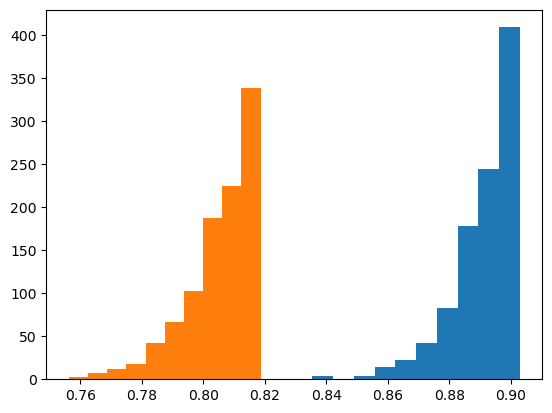

In [214]:
plt.hist(df_alive['mean_alive']);
plt.hist(df_dead[f'{id}']);

In [215]:
df_alive['k_soil_top'] = df_alive['k_soil_sats'].str.split(';').str[0].astype(float)
df_alive['clay_frac_1'] = df_alive['clay_fracs'].str.split(';').str[0].astype(float)
df_alive['clay_frac_2'] = df_alive['clay_fracs'].str.split(';').str[1].astype(float)
df_alive['sand_frac_1'] = df_alive['sand_fracs'].str.split(';').str[0].astype(float)
df_alive['sand_frac_2'] = df_alive['sand_fracs'].str.split(';').str[1].astype(float)

df_dead['k_soil_top'] = df_dead['k_soil_sats'].str.split(';').str[0].astype(float)
df_dead['clay_frac_1'] = df_dead['clay_fracs'].str.split(';').str[0].astype(float)
df_dead['clay_frac_2'] = df_dead['clay_fracs'].str.split(';').str[1].astype(float)
df_dead['sand_frac_1'] = df_dead['sand_fracs'].str.split(';').str[0].astype(float)
df_dead['sand_frac_2'] = df_dead['sand_fracs'].str.split(';').str[1].astype(float)

In [216]:
df['k_xylem_sat']

0      805.537905
1      797.627338
2      687.060064
3      791.664135
4      521.000767
          ...    
995    811.720176
996    776.445529
997    335.739825
998    706.060947
999    847.782262
Name: k_xylem_sat, Length: 1000, dtype: float64

In [205]:
cols = ['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value',
       'psi50_xylem', 'psi88_xylem', 'leaf_hydraulic_capacitance',
       'leaf_area_index', 'psi_leaf_50_close', 'd_50_close', 'g0', 'g1','jackson_root_beta' , 'soil_profile_index','k_soil_top', 'clay_frac_1', 'clay_frac_2', 'sand_frac_1', 'sand_frac_2', 'root_area_index']

In [206]:
len(cols)

19

In [207]:
import matplotlib.pyplot as plt

In [208]:
df.groupby(df['soil_profile_index'])[cols].mean()

,stem_hydraulic_capacitance,k_xylem_sat,huber_value,psi50_xylem,psi88_xylem,leaf_hydraulic_capacitance,leaf_area_index,psi_leaf_50_close,d_50_close,g0,g1,jackson_root_beta,soil_profile_index,k_soil_top,clay_frac_1,clay_frac_2,sand_frac_1,sand_frac_2,root_area_index
soil_profile_index,,,,,,,,,,,,,,,,,,,
0,411.865605,690.624605,0.000281,-3.550587,-4.247479,0.972428,3.459099,-1.983524,3.159268,0.039832,3.190251,0.884857,0.0,2.849364e-07,0.571266,0.324294,0.073955,0.249994,11.765544
1,442.647777,705.031837,0.000281,-3.546535,-4.256417,0.951556,3.444665,-2.000435,3.023962,0.039917,3.214584,0.880398,1.0,3.185431e-07,0.570445,0.326476,0.074750,0.251750,12.102607
2,453.088667,715.355964,0.000277,-3.542911,-4.250956,0.962650,3.373657,-2.024413,3.099790,0.037819,3.212260,0.887416,2.0,1.711527e-07,0.573956,0.324465,0.077562,0.250119,12.134918
3,395.732904,705.365597,0.000276,-3.554987,-4.263098,0.986764,3.320845,-1.980279,3.184785,0.040401,3.172022,0.887082,3.0,3.830125e-07,0.571950,0.327512,0.074233,0.246194,11.777985
4,460.864989,708.996857,0.000279,-3.563678,-4.257953,0.945452,3.403065,-2.018410,3.088790,0.038732,3.161891,0.885625,4.0,4.259949e-07,0.570960,0.327835,0.072170,0.246149,11.539141
5,435.186015,709.042610,0.000278,-3.540860,-4.239016,0.954524,3.468336,-1.990811,2.936934,0.038322,3.062310,0.880730,5.0,3.711461e-07,0.570125,0.322940,0.078066,0.252514,11.809308
6,416.274888,719.653216,0.000276,-3.550386,-4.249814,0.963172,3.502876,-1.989441,3.029976,0.039116,3.194721,0.883439,6.0,2.051496e-07,0.570273,0.324998,0.073882,0.249722,11.942566
7,470.206271,686.141563,0.000281,-3.554427,-4.262475,0.956069,3.396158,-2.015106,3.021809,0.038369,2.943176,0.887255,7.0,2.688819e-07,0.568548,0.325607,0.071296,0.250243,11.885672


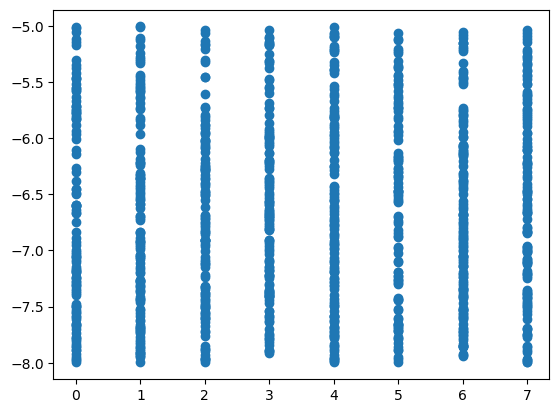

In [209]:
plt.scatter(df_dead['soil_profile_index'],np.log10( df_dead['k_soil_top']))

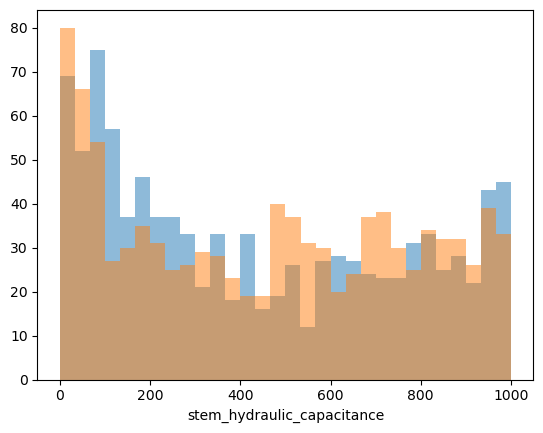

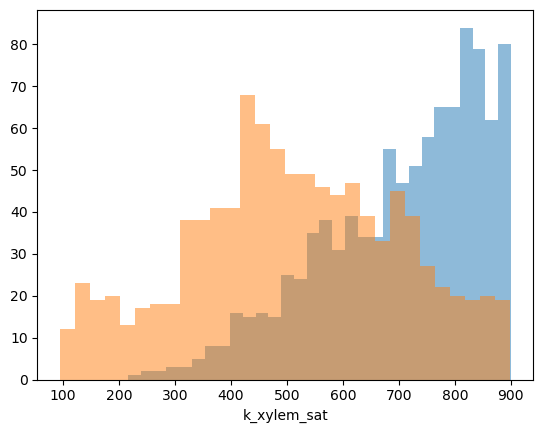

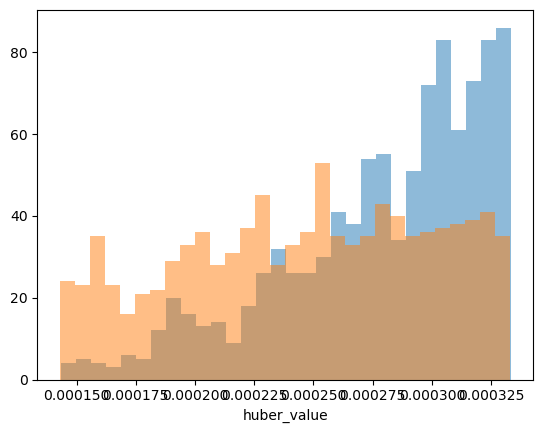

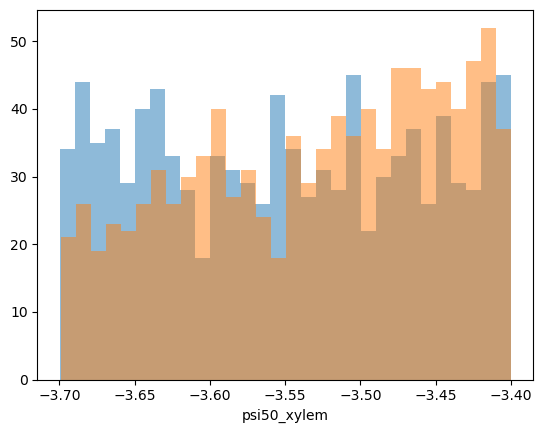

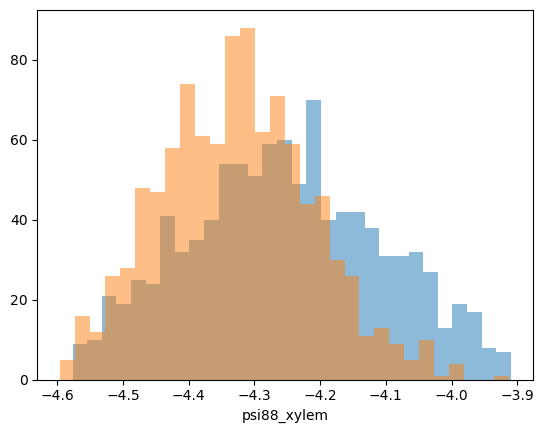

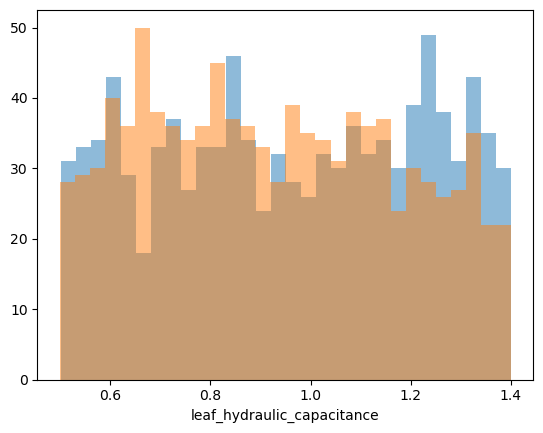

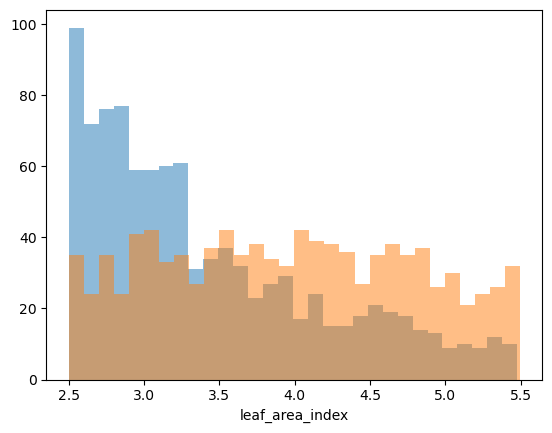

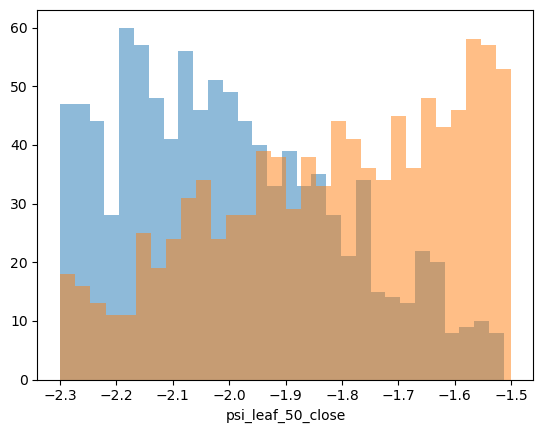

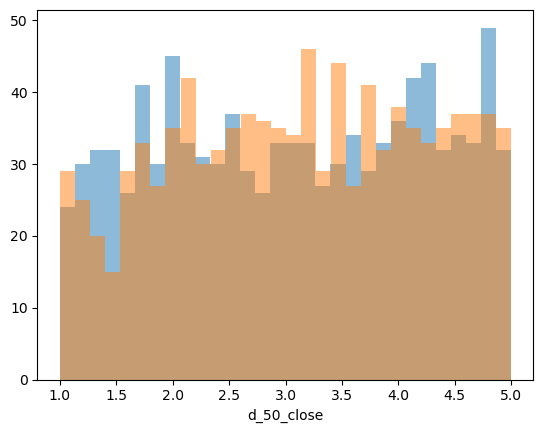

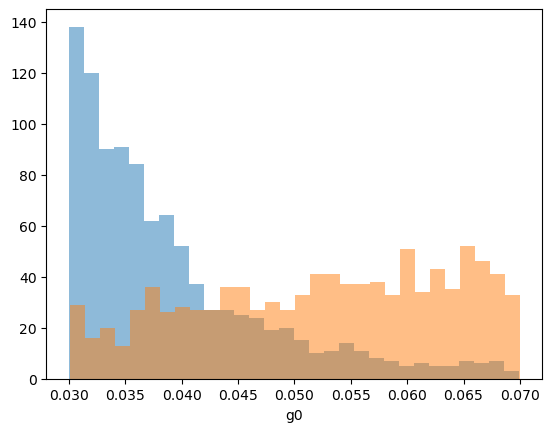

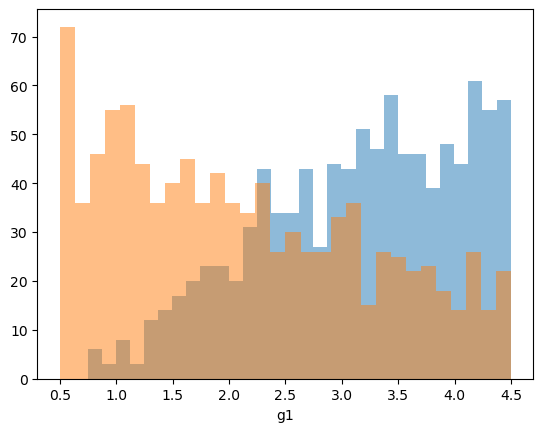

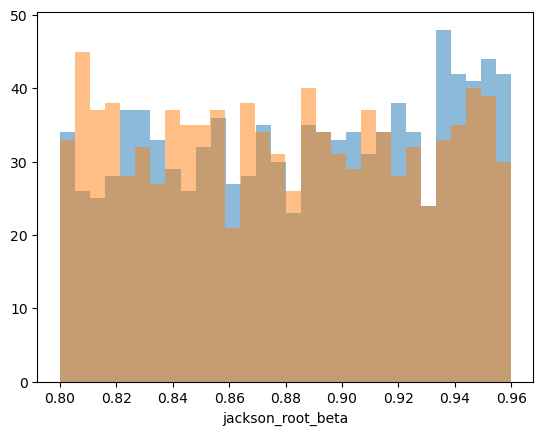

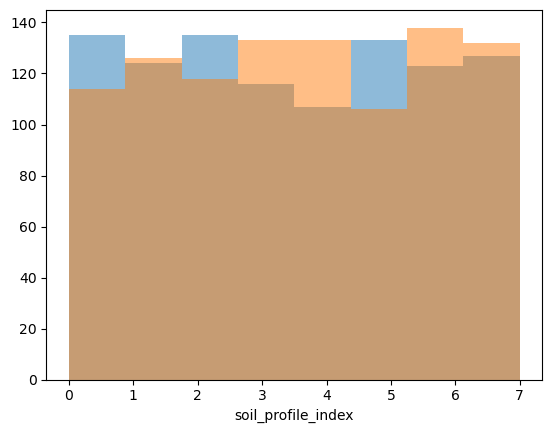

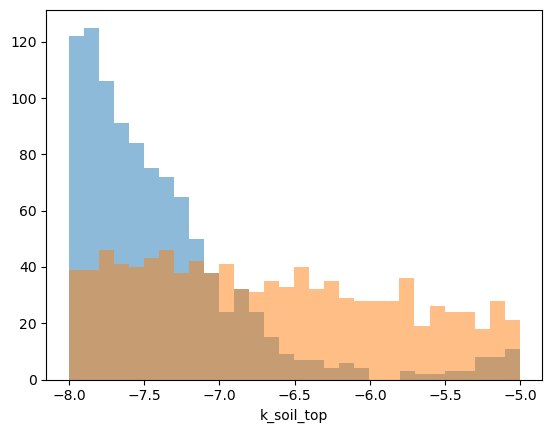

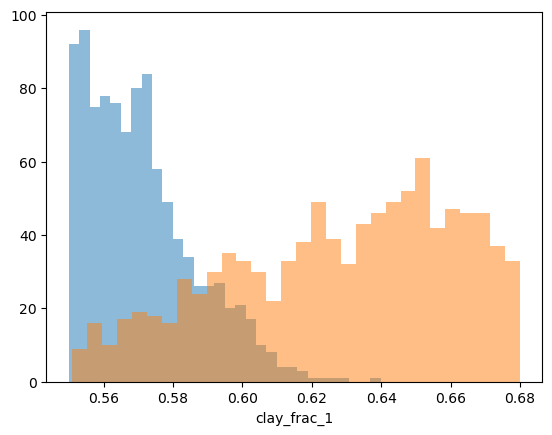

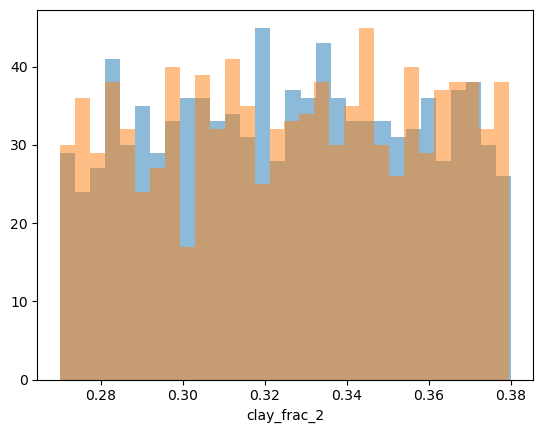

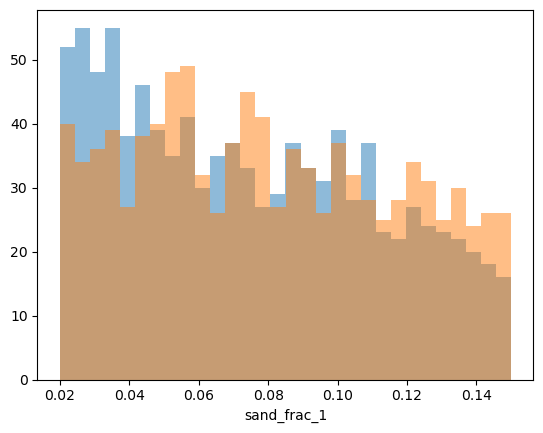

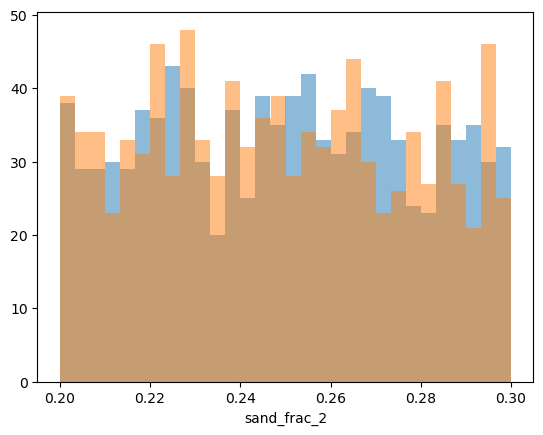

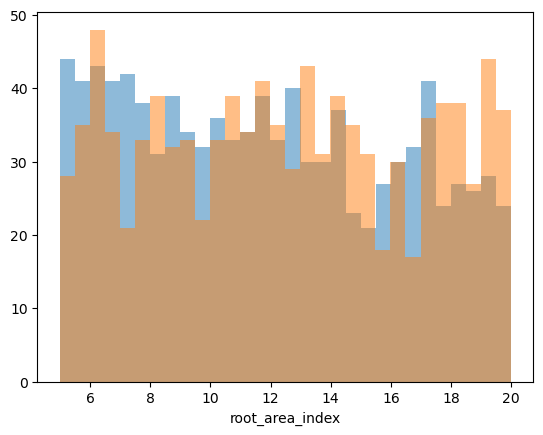

In [210]:
for col in cols:
    bins = 30
    if col == 'soil_profile_index':
        plt.hist(df_alive[col], bins = 8, alpha =0.5)
        plt.hist(df_dead[col], bins = 8,alpha =0.5)
    elif col == 'k_soil_top':
        plt.hist(np.log10(df_alive[col]), bins = bins,alpha =0.5)
        plt.hist(np.log10(df_dead[col]), bins = bins, alpha =0.5)
    else:
        plt.hist(df_alive[col], bins = bins,alpha =0.5)
        plt.hist(df_dead[col], bins = bins,alpha =0.5)
    plt.xlabel(col)
    plt.show()

In [126]:
df[0].describe()

KeyError: 0

In [192]:
df

,Unnamed: 0.1,Unnamed: 0,root_zone_depth,root_area_index,canopy_height,rho_water,grav,stem_flow_type,eta_LS,stem_hydraulic_capacitance,...,9,10,11,12,13,k_soil_top,clay_frac_1,clay_frac_2,sand_frac_1,sand_frac_2
0,395176,395176,0.3,12,20,998,9.81,Linear,1.0,286.854854,...,1.336465,1.700468,1.891229,1.690866,1.659666,4.242551e-13,0.672057,0.356743,0.048116,0.285440
1,862485,862485,0.3,12,20,998,9.81,Linear,1.0,401.065663,...,1.134954,1.727827,1.911139,1.724947,1.698266,2.177664e-12,0.617725,0.335846,0.026258,0.208289
2,217193,217193,0.3,12,20,998,9.81,Linear,1.0,152.135434,...,2.874730,2.080414,2.229343,2.071067,1.989008,7.929020e-12,0.580607,0.312904,0.082100,0.213196
3,300588,300588,0.3,12,20,998,9.81,Linear,1.0,96.069786,...,2.093855,1.885917,2.099715,1.866347,1.845822,2.248108e-15,0.566468,0.325938,0.092599,0.295052
4,983980,983980,0.3,12,20,998,9.81,Linear,1.0,448.266609,...,2.597259,2.165954,2.343825,2.140036,2.120504,4.869511e-11,0.636953,0.363076,0.089014,0.256419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,704371,704371,0.3,12,20,998,9.81,Linear,1.0,874.074055,...,1.775306,1.550974,1.717429,1.535305,1.490910,1.345361e-14,0.580856,0.294871,0.067572,0.206079
9996,619853,619853,0.3,12,20,998,9.81,Linear,1.0,740.398869,...,2.124324,1.591852,1.772640,1.582268,1.539578,2.957329e-12,0.613567,0.308215,0.076419,0.284424
9997,545283,545283,0.3,12,20,998,9.81,Linear,1.0,780.237997,...,2.878195,2.074416,2.277797,2.042343,2.026491,7.648322e-16,0.590798,0.368947,0.109523,0.297208
9998,580254,580254,0.3,12,20,998,9.81,Linear,1.0,999.664119,...,2.575804,1.683476,1.855937,1.645892,1.657360,1.477879e-14,0.572504,0.293834,0.138049,0.249161


In [62]:
df[df[2] < 1.0]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
